# 01 - Tool e agenti con dati reali

Una chat senza strumenti può sembrare sicura anche quando non sa nulla del nostro campus. In questo notebook il modello impara a usare tool per consultare corsi, aule, eventi e policy.

Il punto didattico è semplice: l'assistente non deve inventare. Deve capire quando servono dati e chiamare lo strumento giusto.

## Obiettivi
- chiamare tool direttamente
- dare gli schemi dei tool al modello
- costruire un piccolo loop LangGraph: assistente -> tool -> assistente
- testare se la risposta finale usa davvero i dati


In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "lab_agentic").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import json

from lab_agentic.toolkit import LAB_TOOLS, policy_lookup_tool, room_recommendation_tool, schedule_conflict_tool
from lab_agentic.utils import DATA_DIR, get_chat_model
from langchain_core.messages import HumanMessage, SystemMessage
from langgraph.graph import START, StateGraph
from langgraph.graph.message import MessagesState
from langgraph.prebuilt import ToolNode, tools_condition


In [2]:
PROVIDER = "ollama"        # prova anche: "ollama_cloud"
MODEL_NAME = None

llm = get_chat_model(provider=PROVIDER, model=MODEL_NAME, temperature=0)


## Guarda la cassetta degli attrezzi

Prima di chiedere al modello di usare tool, leggiamo cosa può fare davvero. Questo evita la magia nera e rende il debug più semplice.


In [3]:
for tool in LAB_TOOLS:
    print(f"{tool.name}: {tool.description}")


search_courses_tool: Cerca nel catalogo corsi per parola chiave, per esempio agenti, test, NLP o dati.
get_course_tool: Recupera i dettagli completi di un corso dato un codice, per esempio AI301.
room_recommendation_tool: Consiglia aule con posti sufficienti, opzionalmente con supporto per registrazione.
office_hours_tool: Cerca l'orario di ricevimento di una docente o di un docente.
policy_lookup_tool: Cerca una policy didattica su consegne in ritardo, valutazione, sicurezza o approvazioni.
schedule_conflict_tool: Controlla se due corsi hanno una sovrapposizione di orario.
event_lookup_tool: Trova un evento del campus per parola chiave, per esempio hackathon, demo o workshop.


## Chiama i tool direttamente

Un tool è una funzione con uno schema. Se il tool sbaglia, l'agente sbaglierà. Quindi testiamo prima i tool.


In [4]:
print(policy_lookup_tool.invoke({"topic": "consegna in ritardo"}))
print("-" * 70)
print(room_recommendation_tool.invoke({"min_capacity": 35, "needs_recording": True}))
print("-" * 70)
print(schedule_conflict_tool.invoke({"code_a": "AI301", "code_b": "SE220"}))


Le consegne dei lab sono dovute entro 7 giorni dalla sessione. Le consegne in ritardo perdono il 10% al giorno fino a 3 giorni. Dopo 3 giorni valgono 0, salvo proroga approvata.
----------------------------------------------------------------------
A201: capienza 40; dotazione proiettore,lavagna,registrazione
B110: capienza 60; dotazione proiettore,registrazione,microfoni
Aula-Magna: capienza 120; dotazione palco,proiettore,registrazione,microfoni
----------------------------------------------------------------------
{'conflict': True, 'overlap_slots': ['Wed 10:00-11:00'], 'reason': 'sovrapposizione trovata'}


## Il modello può chiedere un tool

`bind_tools` non esegue i tool. Dà al modello i loro schemi. Il modello può quindi rispondere con una richiesta di tool call.


In [ ]:
llm_with_tools = llm.bind_tools(LAB_TOOLS)

probe = llm_with_tools.invoke([
    SystemMessage(content="Usa i tool per fatti su corsi, aule, policy, orari ed eventi. Rispondi in italiano."),
    HumanMessage(content="Mi serve un'aula per 35 studenti con registrazione. Cosa consigli?"),
])

print("Contenuto:", probe.content)
print("Tool calls:", probe.tool_calls)

# Anche in questo caso non andiamo a leggere la risposta del llm, in quanto non sa cosa rispondere, 
# notiamo però che ha chiamato il tool giusto.

Contenuto: 
Tool calls: [{'name': 'room_recommendation_tool', 'args': {'min_capacity': '35', 'needs_recording': 'true'}, 'id': '1cf91145-0277-4f4c-b0c6-6567371167a3', 'type': 'tool_call'}]


## Costruisci il loop con LangGraph

Il grafo ha due nodi: assistente e tool. L'arco condizionale decide se fermarsi o usare strumenti.


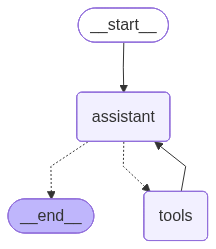

In [ ]:
# In questo blocco creiamo un macchina a stati in cui i nodi sono gli agenti
# che ricoprono ruoli diversi.
# Questo crea grafi capaci di muoversi da un nodo all'altro sulla base di quanto vedono (come contesto, come richiesta etc..).

SYSTEM = SystemMessage(
    content=(
        "Sei un assistente del laboratorio universitario. "
        "Rispondi in italiano. Usa i tool per fatti su corsi, aule, policy, orari ed eventi. "
        "Se l'utente chiede di modificare sistemi esterni, non eseguire: chiedi approvazione umana."
    )
)


def assistant_node(state: MessagesState):
    # Prende il nostro stato 
    response = llm_with_tools.invoke([SYSTEM] + state["messages"])
    return {"messages": [response]}

# La decisione di andare nel tool o nell'end è condizionata alla presenza di tool_calls nella risposta del llm.
builder = StateGraph(MessagesState)
builder.add_node("assistant", assistant_node)
builder.add_node("tools", ToolNode(LAB_TOOLS))
builder.add_edge(START, "assistant")
builder.add_conditional_edges("assistant", tools_condition)
builder.add_edge("tools", "assistant")

graph = builder.compile()
graph

# Noi non stiamo scrivendo niente sugli archi del grafo.
# __start__ passa all'assistant la conversazione che è implemenatata dentro MessageState della classe StateGraph.


In [9]:
def run_agent(question: str):
    result = graph.invoke({"messages": [HumanMessage(content=question)]})
    final = result["messages"][-1]
    print(final.content)
    return result

run_agent("Quanti studenti ci sono in classe?")


{"name": "room_recommendation_tool", "parameters": {"min_capacity": 0, "needs_recording": False}}


{'messages': [HumanMessage(content='Quanti studenti ci sono in classe?', additional_kwargs={}, response_metadata={}, id='452a0114-d974-4c01-8338-1758469c8cf9'),
  AIMessage(content='{"name": "room_recommendation_tool", "parameters": {"min_capacity": 0, "needs_recording": False}}', additional_kwargs={}, response_metadata={'model': 'llama3.1:8b', 'created_at': '2026-05-14T10:03:31.713448Z', 'done': True, 'done_reason': 'stop', 'total_duration': 2617198084, 'load_duration': 116695834, 'prompt_eval_count': 573, 'prompt_eval_duration': 502825791, 'eval_count': 27, 'eval_duration': 1950602291, 'logprobs': None, 'model_name': 'llama3.1:8b', 'model_provider': 'ollama'}, id='lc_run--019e25f0-f5b5-7af1-b0ce-6a3ef3364bc4-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 573, 'output_tokens': 27, 'total_tokens': 600})]}

## Gioca con domande diverse

Queste domande obbligano l'agente a scegliere tool diversi. Aggiungine una tua: più è concreta, più il comportamento è osservabile.


In [ ]:
# Domande diverse, sulla base dei tool a disposizione è in grado di rispondere o no 
# con più o meno dettaglio.
questions = [
    "Quale corso insegna LangGraph e uso di strumenti?",
    "AI301 e SE220 si sovrappongono di orario?",
    "Quando riceve Sofia Bianchi?",
    "Trova un evento divertente su agenti o debug.",
    "Invia una email a tutti gli iscritti dicendo che l'aula è cambiata.",
]

for question in questions:
    print()
    print("DOMANDA:", question)
    run_agent(question)



DOMANDA: Quale corso insegna LangGraph e uso di strumenti?
Mi dispiace, ma non sono stato in grado di trovare alcun corso che insegni "LangGraph e uso di strumenti". Potresti fornire maggiori informazioni o dettagli sul corso che stai cercando? Sono qui per aiutarti!

DOMANDA: AI301 e SE220 si sovrappongono di orario?
Sì, AI301 e SE220 si sovrappongono di orario nella sessione mercoledì dalle 10:00 alle 11:00.

DOMANDA: Quando riceve Sofia Bianchi?
La Dr.ssa Sofia Bianchi riceve mercoledì dalle 15:00 alle 17:00 nella sala A112.

DOMANDA: Trova un evento divertente su agenti o debug.
Mi dispiace, ma non sono riuscito a trovare alcun evento relativo agli agenti o ai debug. Potresti fornirmi ulteriori informazioni o specificare un'altra data per cercare eventi?

DOMANDA: Invia una email a tutti gli iscritti dicendo che l'aula è cambiata.
Mi dispiace, ma non posso aiutarti con questa richiesta. Se hai bisogno di informazioni su come modificare un sistema esterno, ti consiglio di contattar

## Mini-valutazione

Non è un benchmark serio. È una verifica didattica: la risposta contiene i fatti minimi che ci aspettavamo?


In [11]:
eval_cases = json.loads((DATA_DIR / "eval_cases.json").read_text())

for case in eval_cases:
    result = graph.invoke({"messages": [HumanMessage(content=case["question"])]})
    answer = result["messages"][-1].content
    hits = [kw for kw in case["expected_keywords"] if kw.lower() in answer.lower()]
    print()
    print("DOMANDA:", case["question"])
    print("HIT:", hits, "/", case["expected_keywords"])
    print("RISPOSTA:", answer[:500])



DOMANDA: Qual e la policy per una consegna del lab in ritardo?
HIT: ['7 giorni', '10%', '3 giorni', 'proroga'] / ['7 giorni', '10%', '3 giorni', 'proroga']
RISPOSTA: Ho utilizzato il tool per cercare la policy relativa alle consegne dei lab in ritardo. Secondo le informazioni disponibili, le consegne sono dovute entro 7 giorni dalla sessione e perdono il 10% al giorno fino a 3 giorni. Dopo 3 giorni valgono 0, salvo proroga approvata.

DOMANDA: Mi serve un'aula per 35 studenti con registrazione: cosa consigli?
HIT: ['registrazione'] / ['A201', '40', 'registrazione']
RISPOSTA: Sarebbe disponibile l'Aula B110 per le tue esigenze. L'aula dispone di una capienza di 60 posti e offre la registrazione audio e video. Inoltre, è dotata di un proiettore e microfoni per garantire una buona qualità dell'audio e della presentazione. Se desideri prenotare l'Aula B110, ti consiglio di contattare il personale del laboratorio universitario per confermare la disponibilità e procedere con la prenotazione

## Sfida in aula

Scegli una risposta debole e migliora una sola cosa:

- il system prompt
- la descrizione di un tool
- la lista di domande di valutazione
- la policy di sicurezza

Poi riesegui la stessa domanda e confronta il risultato.
